In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

import torch
import hydra
from omegaconf import OmegaConf
from FASCINATION.src.utils import loading_datamodule, unorm_ssp_arr_3D
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

import numpy as np
from tqdm import tqdm
from scipy.ndimage import zoom
import pickle
import xarray as xr
from sklearn.decomposition import PCA


# Functions

In [2]:
def float_to_rgb_image(arr):
    """
    Encode a 2D float32 array (in [0, 1]) into a 3-channel RGB uint8 image.
    """
    assert arr.ndim == 2, "Input must be 2D (H, W)"
    arr = np.clip(arr, 0, 1)
    val = (arr * (256**3 - 1)).astype(np.uint32)  # scale to [0, 16777215]

    r = (val >> 16) & 0xFF
    g = (val >> 8) & 0xFF
    b = val & 0xFF

    rgb = np.stack([r, g, b], axis=-1).astype(np.uint8)  # shape: (H, W, 3)
    return rgb

def save_float_array_as_png(arr, path):
    rgb_img = float_to_rgb_image(arr)
    img = Image.fromarray(rgb_img, mode="RGB")
    img.save(path)

In [3]:
def rgb_image_to_float(arr):
    """
    Decode a 3-channel RGB uint8 image (H, W, 3) back to float32 array in [0, 1].
    """
    r = arr[..., 0].astype(np.uint32)
    g = arr[..., 1].astype(np.uint32)
    b = arr[..., 2].astype(np.uint32)

    val = (r << 16) | (g << 8) | b
    return val.astype(np.float32) / (256**3 - 1)

def load_float_array_from_png(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)
    return rgb_image_to_float(arr)

In [4]:
def normalize_to_uint8(x):
    x = (x - x.min()) / (x.max() - x.min())  # normalize to [0, 1]
    return (x * 255).astype(np.uint8)

# Load Data

In [5]:
gpu = 0
    
if torch.cuda.is_available() and gpu is not None:
##This may not be necessary outside the notebook
    dev = f"cuda:{gpu}"
else:
    dev = "cpu"

device = torch.device(dev)

In [6]:
try:
    if dm_dict:
        print("Not reloading datamodule")

except:
    
    dm_dict = {}
    
    n_components = 0
    print("Initializing datamodule")

Initializing datamodule


In [7]:
data = "enatl"

In [8]:
data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [9]:
xp="autoencoder_V2"

In [10]:
cfg_path = f"config/xp/{xp}.yaml"
cfg = OmegaConf.load(cfg_path)

In [11]:
cfg.paths.sound = data_path[data]

In [12]:
cfg.datamodule.norm_stats.method = "min_max"

In [13]:
cfg.datamodule.reshape["method"] = "factor_64"

The images data have to be in the [0, 1] range

cf https://interdigitalinc.github.io/CompressAI/zoo.html#zoo-training

In [14]:
dm = hydra.utils.call(cfg.datamodule)

In [15]:
train_ssp_arr, test_ssp_arr, dm = loading_datamodule(dm)

dm_dict[cfg.datamodule] = dm

In [16]:
train_ssp_arr.shape, test_ssp_arr.shape

((255, 157, 192, 256), (37, 157, 192, 256))

In [21]:
test_day, depth, height, width = test_ssp_arr.shape 
train_day = train_ssp_arr.shape[0]

In [18]:
# if dm.norm_stats["norm_location"] == "datamodule": 
#     train_ssp_arr, test_ssp_arr = unorm_ssp_arr_3D(train_ssp_arr, dm), unorm_ssp_arr_3D(test_ssp_arr, dm)

In [19]:
# train_ssp_arr.min(), train_ssp_arr.max(), test_ssp_arr.min(), test_ssp_arr.max()

## 1 depth per png

In [63]:

# Create an output directory for PNGs
output_dir = "/Odyssey/private/o23gauvr/input/imgs/depth_channels_1/test/"
os.makedirs(output_dir, exist_ok=True)



for img_idx in tqdm(range(day)):
    for d in range(depth):

        arr = test_ssp_arr[img_idx, d, :, :]
        filename = os.path.join(output_dir, f"{data}_{img_idx:03d}_depth_{d:02d}.png")
        save_float_array_as_png(arr, filename)
        #print(f"Saved {filename}")
        

100%|██████████| 34/34 [01:00<00:00,  1.79s/it]


## 3 depth per png

In [22]:

# Create an output directory for PNGs
output_dir = "/Odyssey/private/o23gauvr/input/imgs/depth_channels_3/train/"
os.makedirs(output_dir, exist_ok=True)

# For each image, we create groups of 3 consecutive slices
num_groups = depth // 3  # 157//3 = 52 (ignores leftover slice)
print(f"Number of RGB groups per image: {num_groups}")

for img_idx in tqdm(range(train_day)):
    for group_idx in range(num_groups):
        start = group_idx * 3
        end = start + 3
        # Extract a group of 3 consecutive slices; shape: (3, height, width)
        arr = train_ssp_arr[img_idx, start:end, :, :]
        #rgb = normalize_to_uint8(arr)  # Normalize to [0, 255]
        rgb = transforms.ToPILImage(mode="RGB")(arr.transpose(1, 2, 0))

        filename = os.path.join(output_dir, f"{data}_{img_idx:03d}_group_{group_idx:02d}.png")
        rgb.save(filename)
        #Image.fromarray(rgb, mode='RGB').save(filename)
        #print(f"Saved {filename}")
        

Number of RGB groups per image: 52


100%|██████████| 255/255 [03:32<00:00,  1.20it/s]


In [20]:
arr = test_ssp_arr[-1, -3:, :, :]

In [21]:
test_ssp_arr.min(), test_ssp_arr.max(), train_ssp_arr.min(), train_ssp_arr.max()

(0.007643433, 0.96360964, 0.0, 1.0)

In [22]:
arr.mean(), arr.min(), arr.max()

(0.290512, 0.25664535, 0.3136643)

In [24]:
rgb = transforms.ToPILImage(mode="RGB")(arr.transpose(1, 2, 0))

In [26]:
np.array(rgb).mean(), np.array(rgb).min(), np.array(rgb).max()

(73.57916259765625, 65, 79)

## pca components

In [42]:
max_comp = 6

In [43]:
flatten_train_ssp_arr = train_ssp_arr.transpose(0,2,3,1).reshape(-1, depth)
flatten_test_ssp_arr = test_ssp_arr.transpose(0,2,3,1).reshape(-1, depth)

In [44]:
pca = PCA(n_components=max_comp)
pca.fit(flatten_train_ssp_arr)
test_pca = pca.transform(flatten_test_ssp_arr).reshape(day, height, width, max_comp).transpose(0, 3, 1, 2)
print(f"Test PCA shape: {test_pca.shape}")

Test PCA shape: (34, 6, 192, 256)


### 1 pca components per png

In [68]:

# Create an output directory for PNGs
output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels_1/test/"
os.makedirs(output_dir, exist_ok=True)



for img_idx in tqdm(range(day)):
    for d in range(max_comp):
        arr = test_pca[img_idx, d, :, :]
        filename = os.path.join(output_dir, f"{data}_{img_idx:03d}_pca_{d:02d}.png")
        save_float_array_as_png(arr, filename)
        #print(f"Saved {filename}")
        

100%|██████████| 34/34 [00:01<00:00, 24.82it/s]


### 3 pca components per png

In [45]:

# Create an output directory for PNGs
output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels_3/test/"
os.makedirs(output_dir, exist_ok=True)

# For each image, we create groups of 3 consecutive slices
num_groups = max_comp // 3  # 157//3 = 52 (ignores leftover slice)
print(f"Number of RGB groups per image: {num_groups}")

for img_idx in tqdm(range(day)):
    for group_idx in range(num_groups):
        start = group_idx * 3
        end = start + 3
        # Extract a group of 3 consecutive slices; shape: (3, height, width)
        arr = test_pca[img_idx, start:end, :, :]
        rgb = transforms.ToPILImage(mode="RGB")(arr.transpose(1, 2, 0))

        filename = os.path.join(output_dir, f"{data}_{img_idx:03d}_group_{group_idx:02d}.png")
        rgb.save(filename)
        #print(f"Saved {filename}")
        

Number of RGB groups per image: 2


100%|██████████| 34/34 [00:07<00:00,  4.37it/s]


In [ ]:
img = Image.open("/Odyssey/private/o23gauvr/input/videos/sequences/071/img_31.png")
print("Image size:", img.size)
img.show()

Image size: (256, 256)


Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)


In [ ]:

# # Create an output directory for PNGs
# output_dir = "/Odyssey/private/o23gauvr/input/videos/sequences/"
# os.makedirs(output_dir, exist_ok=True)

# num_images, num_slices, height, width = test_ssp_arr_resized.shape  # (255,157,140,240)
# print(f"Array shape: {test_ssp_arr_resized.shape}")

# # For each image, we create groups of 3 consecutive slices
# num_groups = num_slices // desired_shape[0]  # 157//3 = 52 (ignores leftover slice)
# print(f"Number of RGB groups per image: {num_groups}")

# for img_idx in tqdm(range(num_images)):
#     os.makedirs(os.path.join(output_dir,f"{img_idx+255:03d}"), exist_ok=True)
#     for j,group_idx in enumerate(range(num_groups)):

#         start = group_idx * 3
#         end = start + 3
#         # Extract a group of 3 consecutive slices; shape: (3, height, width)
#         rgb = test_ssp_arr_resized[img_idx, start:end, :, :]
#         # Rearrange to (height, width, 3) for saving with PIL.Image
#         rgb_img = np.transpose(rgb, (1, 2, 0))

#         rgb_normalized = 255 * (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
#         rgb_uint8 = rgb_normalized.astype(np.uint8)
        
#         filename = os.path.join(output_dir, f"{img_idx+255:03d}/img_{group_idx:02d}.png")
#         Image.fromarray(rgb_uint8, mode='RGB').save(filename)
#         #print(f"Saved {filename}")
        

Array shape: (37, 157, 256, 256)
Number of RGB groups per image: 52


100%|██████████| 37/37 [00:51<00:00,  1.40s/it]


In [ ]:
# output_dir = "/Odyssey/private/o23gauvr/input/videos/"
# with open(f'{os.path.join(output_dir,"test.list")}', "w") as f:
#     for i in range(255, 292):
#         #for j in range(52):
#             #path = os.path.join(,f"img_{j:02d}.png\n")
#         f.write(f"{i:03d}/\n")

In [ ]:
# output_dir = "/Odyssey/private/o23gauvr/input/videos/"
# with open(f'{os.path.join(output_dir,"train.list")}', "w") as f:
#     for i in range(255):
#         #for j in range(52):
#             #path = os.path.join()
#         f.write(f"{i:03d}/\n")

In [ ]:
# print(f"Saved list to {output_dir}/train.list")

Saved list to /Odyssey/private/o23gauvr/input/videos/sequences//train.list


# Directly from xarray

Images not normalized with shape factor of 64

In [100]:
data = "natl"

In [101]:
data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [102]:
da = xr.open_dataarray(data_path[data])

In [103]:
da

<xarray.DataArray 'celerity' (time: 335, z: 300, lat: 240, lon: 240)>
[5788800000 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * lat      (lat) float64 32.0 32.05 32.1 32.15 32.2 ... 43.8 43.85 43.9 43.95
  * z        (z) float64 0.4805 1.559 2.794 ... 5.925e+03 5.975e+03 6.025e+03
  * time     (time) datetime64[ns] 2012-10-01T12:00:00 ... 2013-09-30T12:00:00

In [104]:
da = da.sel(z=da.z[da.z < 2000])
da

<xarray.DataArray 'celerity' (time: 335, z: 157, lat: 240, lon: 240)>
[3029472000 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * lat      (lat) float64 32.0 32.05 32.1 32.15 32.2 ... 43.8 43.85 43.9 43.95
  * z        (z) float64 0.4805 1.559 2.794 ... 1.937e+03 1.958e+03 1.98e+03
  * time     (time) datetime64[ns] 2012-10-01T12:00:00 ... 2013-09-30T12:00:00

In [ ]:
da=da.dropna(dim="lat")

In [ ]:
lat_reshape= int(np.ceil(da.lat.size/64)*64)
lon_reshape= int(np.ceil(da.lon.size/64)*64)

new_lat = np.linspace(da.lat.min(), da.lat.max(), lat_reshape)
new_lon = np.linspace(da.lon.min(), da.lon.max(), lon_reshape)

da=da.interp(lat=new_lat, lon=new_lon, method="cubic")
                

In [ ]:

da_min = da.min()
da_max = da.max()
da_normalized = (da - da_min) / (da_max - da_min)

In [109]:
da

<xarray.DataArray 'celerity' (time: 335, z: 157, lat: 192, lon: 256)>
array([[[[1539.1852249 , 1539.17145674, 1539.14006415, ...,
          1537.76097412, 1537.79310152, 1537.83730363],
         [1539.14911421, 1539.13657836, 1539.10656254, ...,
          1537.7076451 , 1537.74939035, 1537.80853965],
         [1539.06335696, 1539.03964253, 1538.99942019, ...,
          1537.62401823, 1537.73714392, 1537.82511838],
         ...,
         [1515.14596501, 1515.09680902, 1515.41643532, ...,
          1523.71020017, 1523.32210541, 1523.16416973],
         [1514.92416589, 1514.98666335, 1515.0345297 , ...,
          1523.04889176, 1523.19028045, 1523.59081999],
         [1513.84879495, 1514.22219911, 1514.53991339, ...,
          1523.30378153, 1523.76651264, 1524.17533588]],

        [[1539.12213865, 1539.10937939, 1539.07884187, ...,
          1537.68849948, 1537.71911949, 1537.76197695],
         [1539.08514033, 1539.07356616, 1539.044526  , ...,
          1537.63552691, 1537.67586344, 1537.73377894],
         [1538.99782114, 1538.9748965 , 1538.93555574, ...,
          1537.55237044, 1537.66463984, 1537.75163586],
...
         [1497.29174283, 1497.23132925, 1497.17304092, ...,
          1497.65918387, 1497.61466613, 1497.60332617],
         [1497.4042142 , 1497.33143408, 1497.25648774, ...,
          1497.67326113, 1497.62101278, 1497.60257971],
         [1497.45043403, 1497.41696991, 1497.36502387, ...,
          1497.66607594, 1497.61226915, 1497.6026604 ]],

        [[1498.51717871, 1498.49474166, 1498.53067692, ...,
          1498.5537896 , 1498.55339958, 1498.55261179],
         [1498.48558613, 1498.42591854, 1498.42410699, ...,
          1498.56978293, 1498.53013882, 1498.51507675],
         [1498.47270258, 1498.42120592, 1498.41135978, ...,
          1498.55063875, 1498.50303688, 1498.48642512],
         ...,
         [1497.60279264, 1497.54792883, 1497.49583869, ...,
          1497.96787902, 1497.93202148, 1497.92830705],
         [1497.72211281, 1497.64784936, 1497.57549033, ...,
          1497.98550809, 1497.93925294, 1497.92663384],
         [1497.76695703, 1497.73589326, 1497.68452286, ...,
          1497.98275179, 1497.93390583, 1497.92610186]]]])
Coordinates:
  * z        (z) float64 0.4805 1.559 2.794 ... 1.937e+03 1.958e+03 1.98e+03
  * time     (time) datetime64[ns] 2012-10-01T12:00:00 ... 2013-09-30T12:00:00
  * lat      (lat) float64 32.6 32.64 32.69 32.73 ... 41.02 41.06 41.11 41.15
  * lon      (lon) float64 -65.95 -65.9 -65.86 -65.81 ... -54.09 -54.05 -54.0

In [110]:
# output_path = "/Odyssey/private/o23gauvr/input/NATL60_2000_192_256.nc"
# da.to_netcdf(output_path)
# print(f"NetCDF file saved to {output_path}")

In [111]:
# output_path = "/Odyssey/private/o23gauvr/input/NATL60_2000_192_256.nc"

# da = xr.open_dataarray(output_path)
# da

In [112]:
da.values.shape

(335, 157, 192, 256)

In [113]:
arr = da.values.transpose(0,2,3,1).reshape(-1,da.shape[1])
arr.shape

(16465920, 157)

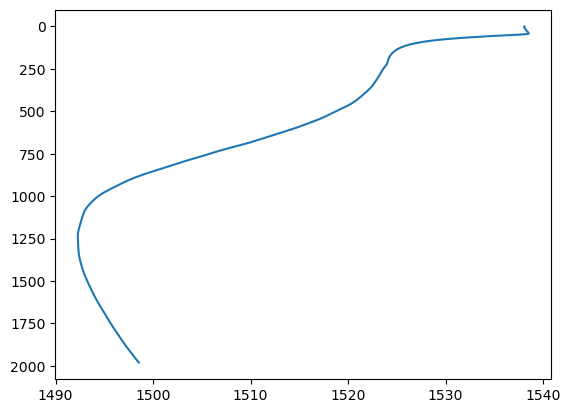

In [114]:
plt.plot(arr[1000,:],da.z.values)
plt.gca().invert_yaxis()

In [115]:
max_comp = 5

In [116]:
pca = PCA(n_components=max_comp)
pca_arr = pca.fit_transform(arr)
pca_arr.shape

(16465920, 5)

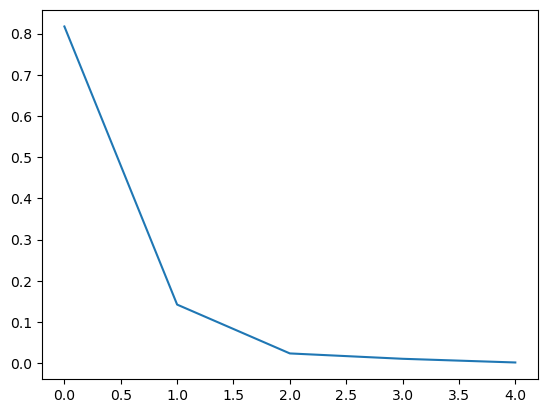

In [117]:
plt.plot(pca.explained_variance_ratio_)

In [118]:
pca_arr = pca_arr.reshape(da.shape[0],da.shape[2],da.shape[3],max_comp).transpose(0,3,1,2)
pca_arr.shape

(335, 5, 192, 256)

In [ ]:


n_times = len(da.time)

rng = np.random.default_rng(42)
time_indices = rng.permutation(n_times)
train_size = int(0.9 * n_times)
train_time_idx = time_indices[:train_size]
test_time_idx = time_indices[train_size:]
# da = da.isel(time=train_time_idx)
train_time_idx




array([295, 101,   0,  26, 252, 181, 205, 174, 132, 241, 126, 328, 333,
       104, 138,  46, 200,  50, 115, 118, 268, 164, 161, 317, 250, 218,
       280, 285,  77, 127,  61, 278, 100,  19, 314,  80,  84, 230,  64,
       183,   3, 306, 274,  24, 146, 197,   2, 245,  51, 173,  33,  47,
         8, 310, 196,  56, 154, 192,  27, 297, 324, 293, 332, 292, 201,
       166, 301, 249, 326,  38, 308, 260,  98, 319,  68, 282,  29, 316,
        82,  12, 247, 235, 265, 318,  30, 266, 107,  25, 169, 143, 207,
        40, 202, 313, 216, 156,  75, 179, 262, 135, 277, 264, 244, 261,
       144,  58, 284, 215,  89, 162, 238,  70, 145, 226, 131,  54, 152,
       150,  62, 213, 165,  53, 148,  96, 159, 134, 229, 294, 299, 288,
        95, 178,  92, 231, 171,   7, 281, 180,  60, 149,  88, 242, 158,
       257, 191,  37, 256, 305, 307,  20, 334, 168, 112, 254, 153, 203,
       184,  79, 239,  66,   9, 204, 209,  59, 151, 325, 232,   4, 172,
        48,  67, 236,  94, 185, 228, 124,  72, 133, 330, 259,  3

In [120]:
train_pca_arr = pca_arr[train_time_idx,...]
test_pca_arr = pca_arr[test_time_idx,...]
train_pca_arr.shape, test_pca_arr.shape

((301, 5, 192, 256), (34, 5, 192, 256))

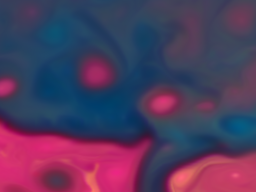

In [122]:
img = train_pca_arr[0,:3,...]
img = normalize_to_uint8(img)
img = Image.fromarray(np.transpose(img, (1, 2, 0)), mode="RGB")
img 

In [123]:
img_array = np.array(img).astype(np.float32)

# Reverse the normalization (assuming the original range is known)
# Replace `original_min` and `original_max` with the actual values
original_min = train_pca_arr.min()  # Replace with the actual min value
original_max = train_pca_arr.max()  # Replace with the actual max value

# Normalize back to the original range
img_float = img_array / 255.0 * (original_max - original_min) + original_min

img_float = img_float.transpose(2,0,1)

In [124]:
np.sqrt(np.mean((img_float - train_pca_arr[0,:3,...])**2))

14.348795188557997

In [125]:
train_pca_arr[0,0,0,0] 

-45.25404815683274

In [126]:
img_float[0,0,0]

-43.101883

In [129]:
img = train_pca_arr[0, 0, ...]
img_min, img_max = img.min(), img.max()
img = (img - img_min) / (img_max - img_min)
rgb = float_to_rgb_image(img)
# img = img * (256 ** 3 - 1)
# print(img.max(), img.min())
# img_2 = img.astype(np.int32) 
# print(img_2.max(), img_2.min())
rgb = Image.fromarray(rgb, mode="RGB")

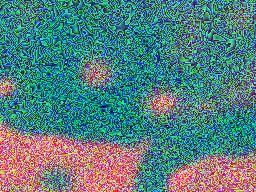

In [130]:
rgb

In [131]:
reconstructed_arr = rgb_image_to_float(np.array(rgb))
reconstructed_arr = (reconstructed_arr * (img_max - img_min)) + img_min
reconstructed_arr.shape

(192, 256)

In [132]:
np.sqrt(np.mean((reconstructed_arr - train_pca_arr[0, 0, ...])**2))

1.2562005633042946e-05

In [133]:
output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels/train/"
os.makedirs(output_dir, exist_ok=True)

for i in tqdm(range(train_pca_arr.shape[0])):
    for j in range(max_comp):

        arr = train_pca_arr[i,j,...]
        path = os.path.join(output_dir, f"{data}_{i:03d}_{j:02d}.png")
        save_float_array_as_png(arr, path)


100%|██████████| 301/301 [00:06<00:00, 48.20it/s]


In [134]:
output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels/test/"
os.makedirs(output_dir, exist_ok=True)

for i in tqdm(range(test_pca_arr.shape[0])):
    for j in range(max_comp):
        
        arr = train_pca_arr[i,j,...]
        path = os.path.join(output_dir, f"{data}_{i:03d}_{j:02d}.png")
        save_float_array_as_png(arr, path)

100%|██████████| 34/34 [00:01<00:00, 18.69it/s]


In [135]:
# output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels_1_3/test/"
# os.makedirs(output_dir, exist_ok=True)

# for i in tqdm(range(test_pca_arr.shape[0])):
#     img = train_pca_arr[i,:3,...]
#     img = normalize_to_uint8(img)
#     img = Image.fromarray(np.transpose(img, (1, 2, 0)), mode="RGB")
#     img.save(os.path.join(output_dir, f"{data}_{i:03d}.png"))

In [136]:
# output_dir = "/Odyssey/private/o23gauvr/input/imgs/pca_channels_4_6/train/"
# os.makedirs(output_dir, exist_ok=True)

# for i in tqdm(range(train_pca_arr.shape[0])):
#     img = train_pca_arr[i,3:6,...]
#     img = normalize_to_uint8(img)
#     img = Image.fromarray(np.transpose(img, (1, 2, 0)), mode="RGB")
#     img.save(os.path.join(output_dir, f"{data}_{i:03d}.png"))

## SST to png

In [40]:
data = "natl"

In [41]:
sst_path = {"enatl":"/Odyssey/public/enatl60/sst/eNATL60-BLB002-SST-2009-2010-1_20.nc",
            "natl":"/Odyssey/public/natl60/sst/NATL60-CJM165-SST-2009-2010-1_20.nc"}


In [42]:
ssp_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60-CJM165-SST-2009-2010-1_20.nc"}

In [43]:
sst = xr.open_dataarray(sst_path[data],engine="netcdf4")
sst

PermissionError: [Errno 13] Permission denied: '/Odyssey/public/natl60/sst/NATL60-CJM165-SST-2009-2010-1_20.nc'

In [ ]:
reduced_coords = xr.open_dataarray(ssp_path[data]).coords
reduced_coords


Coordinates:
  * lon      (lon) float64 -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * lat      (lat) float64 32.0 32.05 32.1 32.15 32.2 ... 43.8 43.85 43.9 43.95
  * z        (z) float64 0.4805 1.559 2.794 ... 5.925e+03 5.975e+03 6.025e+03
  * time     (time) datetime64[ns] 2009-07-01T12:00:00 ... 2010-06-30T12:00:00

In [ ]:
sst = sst.sel(lat=reduced_coords["lat"], lon=reduced_coords["lon"], method="nearest")
sst

<xarray.DataArray 'sst' (time: 365, lat: 240, lon: 240)>
[21024000 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * lat      (lat) float64 32.0 32.05 32.1 32.15 32.2 ... 43.8 43.85 43.9 43.95
  * time     (time) datetime64[ns] 2009-07-01T12:00:00 ... 2010-06-30T12:00:00

In [ ]:
lat_reshape= int(np.ceil(sst.lon.size/64)*64)
lat_reshape

256

In [ ]:
lat_reshape= int(np.ceil(sst.lat.size/64)*64)
lon_reshape= int(np.ceil(sst.lon.size/64)*64)

new_lat = np.linspace(sst.lat.min(), sst.lat.max(), lat_reshape)
new_lon = np.linspace(sst.lon.min(), sst.lon.max(), lon_reshape)

sst=sst.interp(lat=new_lat, lon=new_lon, method="cubic")


In [ ]:
sst_min = sst.min()
sst_max = sst.max()
sst = (sst - sst_min) / (sst_max - sst_min)

In [ ]:


n_times = len(sst.time)

rng = np.random.default_rng(42)
time_indices = rng.permutation(n_times)
train_size = int(0.9 * n_times)
train_time_idx = time_indices[:train_size]
test_time_idx = time_indices[train_size:]
# da = da.isel(time=train_time_idx)
sst_train_arr = sst.isel(time=train_time_idx).values
sst_test_arr = sst.isel(time=test_time_idx).values

sst_train_arr.shape, sst_test_arr.shape


((328, 256, 256), (37, 256, 256))

In [ ]:
output_dir = "/Odyssey/private/o23gauvr/input/imgs/sst/train/"
os.makedirs(output_dir, exist_ok=True)

for i in tqdm(range(sst_train_arr.shape[0])):
    

    arr = sst_train_arr[i,...]
    path = os.path.join(output_dir, f"{data}_{i:03d}.png")
    save_float_array_as_png(arr, path)

  0%|          | 0/328 [00:00<?, ?it/s]

100%|██████████| 328/328 [00:04<00:00, 72.51it/s]


In [ ]:
output_dir = "/Odyssey/private/o23gauvr/input/imgs/sst/test/"
os.makedirs(output_dir, exist_ok=True)

for i in tqdm(range(sst_test_arr.shape[0])):
    

    arr = sst_test_arr[i,...]
    path = os.path.join(output_dir, f"{data}_{i:03d}.png")
    save_float_array_as_png(arr, path)

  0%|          | 0/37 [00:00<?, ?it/s]

100%|██████████| 37/37 [00:00<00:00, 70.81it/s]
